NOTE: Code end at cell 20 from EDA...Using "cleaned_sp500.csv" for continued analysis

# Setup

## Loading Libraries

In [1]:
# Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
# import gdelt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, log_loss, brier_score_loss, precision_score, recall_score, f1_score,
    roc_curve, auc
)

import pandas_ta as ta
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Set plotting style for EDA
sns.set_theme(style="whitegrid")

## Helper functions

In [ ]:
# FUNCTION: Displaying columns of missing values and number of missing values
def na_check(df):

    missing = df.isnull().sum()
    
    if missing.sum() == 0:
        print("\nNo missing values found in the DataFrame.")
    else:
        print("\nThere are missing values that need to be handled...\n")
        print("Missing Values per column:")
        print(missing[missing > 0])


In [ ]:
# FUNCTION: Getting info on dataset and columns
def unique_table(df):

    # Dataset Info
    unique_tickers = df["Ticker"].unique()
    print("Total Tickers (Companies): ", len(unique_tickers))
    print("Dataset Shape:", df.shape[0], "x", df.shape[1]) 

    # Getting Column Info
    unique_counts = pd.DataFrame({
        'Column': df.columns,
        'Unique': df.nunique().values,
        'Data_Type': df.dtypes.values,
        'Sample_Values': [df[col].unique().tolist() for col in df.columns]
    })

    return unique_counts

## Loading Dataset

In [4]:
# Creating dataframe from .csv
sp500_original = pd.read_csv('final_sp500_data.csv')
# sp500_original = pd.read_csv("cleaned_sp500.csv", parse_dates=["Date"]).set_index(["Ticker", "Ticker"]).sort_index()

# Converting data types
sp500_original['Date'] = pd.to_datetime(sp500_original['Date'])
sp500_original['Sector'] = sp500_original['Sector'].astype('category')
sp500_original['Industry'] = sp500_original['Industry'].astype('category')

# Sort by Ticker, then Date
sp500_original = sp500_original.sort_values(by=['Ticker', 'Date'])

# Confirming dataset
print(sp500_original.shape)

(1883792, 12)


# EDA

### Unique Values

In [6]:
unique = unique_table(sp500_original)
unique

Total Tickers (Companies):  503
Dataset Shape: 1883792 x 12


,Column,Unique,Data_Type,Sample_Values
0,Date,3989,datetime64[ns],"[2010-01-04 00:00:00, 2010-01-05 00:00:00, 201..."
1,Ticker,503,object,"[A, AAPL, ABBV, ABNB, ABT, ACGL, ACN, ADBE, AD..."
2,Company,503,object,"[Agilent Technologies Inc, Apple Inc, AbbVie I..."
3,Sector,11,category,"[Health Care, Information Technology, Consumer..."
4,Industry,129,category,"[Life Sciences Tools & Services, Technology Ha..."
5,Open,1655353,float64,"[19.94887170398882, 19.83448151446589, 19.6056..."
6,High,1658302,float64,"[20.101396541348887, 19.840836222190536, 19.70..."
7,Low,1657181,float64,"[19.78363745202544, 19.54849763720313, 19.5485..."
8,Close,1539422,float64,"[19.89167594909668, 19.67560195922852, 19.6056..."
9,Volume,382897,int64,"[3815561, 4186031, 3243779, 3095172, 3733918, ..."


### Missing Values (Initial) and Heatmap of Missing Values


No missing values found in the DataFrame.


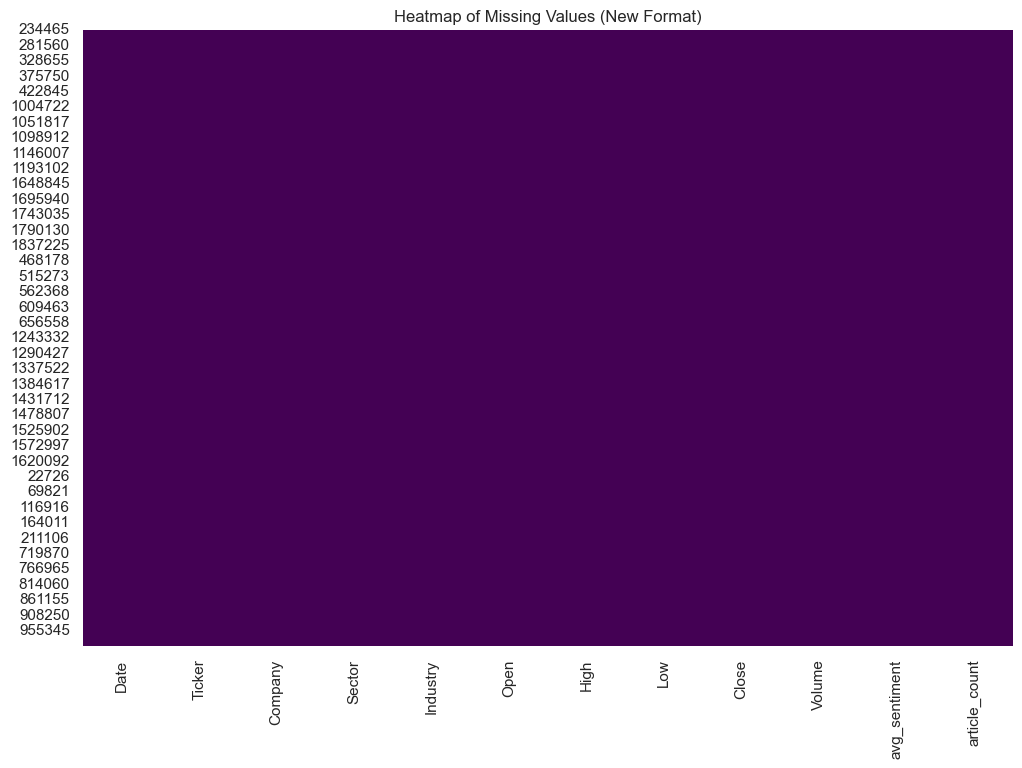

In [7]:
na_check(sp500_original)

# Create a heatmap of missing values
plt.figure(figsize=(12, 8))
sns.heatmap(sp500_original.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values (New Format)')
plt.show()


## Feature Engineering

Additional columns are added prior to cutoff date.

In [ ]:
# Creating seperate dataframe for analysis
df = sp500_original.copy()

# Create new datasets for analysis below:



#### Volume-weighted Fearues (VWAP)

In [9]:
# # VOLUME-WEIGHTED AVERAGE PRICE FEATURES (VWAP)

# print("Calculating VWAP features...")

# df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
# df['Dollar_Volume'] = df['Typical_Price'] * df['Volume']

# # Rolling VWAPs
# roll_5d_dollar = df.groupby('Ticker')['Dollar_Volume'].transform(lambda x: x.rolling(window=5).sum())
# roll_5d_vol = df.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(window=5).sum())
# df['Rolling_VWAP_5D'] = roll_5d_dollar / roll_5d_vol

# roll_21d_dollar = df.groupby('Ticker')['Dollar_Volume'].transform(lambda x: x.rolling(window=21).sum())
# roll_21d_vol = df.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(window=21).sum())
# df['Rolling_VWAP_21D'] = roll_21d_dollar / roll_21d_vol

# # Periodic Monthly AVWAP
# df['YearMonth'] = df['Date'].dt.to_period('M') # Assumes 'Date' is a column; if it's the index, use df.index.to_period('M')
# cum_dollar_vol = df.groupby(['Ticker', 'YearMonth'])['Dollar_Volume'].transform('cumsum')
# cum_vol = df.groupby(['Ticker', 'YearMonth'])['Volume'].transform('cumsum')
# df['Monthly_AVWAP'] = cum_dollar_vol / cum_vol

# # Clean up VWAP intermediate columns
# df.drop(columns=['Typical_Price', 'Dollar_Volume', 'YearMonth'], inplace=True)

# print("Completed...")


In [10]:
df.columns

Index(['Date', 'Ticker', 'Company', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Volume', 'avg_sentiment', 'article_count'],
      dtype='object')

#### Technical Findicators (using pandas_ta library)

In [11]:
# TECHNICAL INDICATORS (pandas_ta)

print("Calculating technical indicators...")

grouped = df.groupby('Ticker')

# Simple single-column indicators
df['SMA_3d'] = grouped['Close'].transform(lambda x: ta.sma(x, length=3))
df['SMA_5d'] = grouped['Close'].transform(lambda x: ta.sma(x, length=5))
df['SMA_20d'] = grouped['Close'].transform(lambda x: ta.sma(x, length=20))
df['SMA_50d'] = grouped['Close'].transform(lambda x: ta.sma(x, length=50))
df['RSI_14d'] = grouped['Close'].transform(lambda x: ta.rsi(x, length=14))

# Robust multi-column indicator function
def apply_ta_indicators(group):
    macd = ta.macd(group['Close'], fast=12, slow=26, signal=9)
    bbands = ta.bbands(group['Close'], length=20)
    
    indicators = [i for i in [macd, bbands] if i is not None]
    return pd.concat(indicators, axis=1) if indicators else None

# Apply multi-column indicators and join to main dataframe
indicator_df = grouped.apply(apply_ta_indicators).reset_index(level=0, drop=True)
df = df.join(indicator_df)

print("Completed...")

Calculating technical indicators...


C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\3889472135.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  indicator_df = grouped.apply(apply_ta_indicators).reset_index(level=0, drop=True)


Completed...


In [12]:
df.columns

Index(['Date', 'Ticker', 'Company', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Volume', 'avg_sentiment', 'article_count', 'SMA_3d',
       'SMA_5d', 'SMA_20d', 'SMA_50d', 'RSI_14d', 'MACD_12_26_9',
       'MACDh_12_26_9', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0',
       'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0'],
      dtype='object')

#### Custom MACD Filters

In [13]:
print("Applying MACD filters...")

# Getting MACD and Signal column names
macd_col = 'MACD_12_26_9'
signal_col = 'MACDs_12_26_9'

# Shifting data by 1 day to detect crossovers
df['MACD_Prev'] = df.groupby('Ticker')[macd_col].shift(1)
df['Signal_Prev'] = df.groupby('Ticker')[signal_col].shift(1)

# Defining standard crossovers
bullish_cross = (df[macd_col] > df[signal_col]) & (df['MACD_Prev'] <= df['Signal_Prev'])
bearish_cross = (df[macd_col] < df[signal_col]) & (df['MACD_Prev'] >= df['Signal_Prev'])

# Trend Filter: Aligning with momentum (Zero Line)
df['Trend_Long'] = bullish_cross & (df[macd_col] > 0)
df['Trend_Short'] = bearish_cross & (df[macd_col] < 0)

# Reversal Filter: Countering momentum
df['Reversal_Long'] = bullish_cross & (df[macd_col] < 0)
df['Reversal_Short'] = bearish_cross & (df[macd_col] > 0)

# Cleaning up MACD intermediate columns
df.drop(columns=['MACD_Prev', 'Signal_Prev'], inplace=True)

print("Completed...")


Applying MACD filters...
Completed...


#### Price and Volume Momentum Features

In [ ]:
print("Calculating momentum features...")

# Creating columns for daily returns and volume changes
df['daily_return'] = df.groupby('Ticker')['Close'].pct_change()
df['daily_vol'] = df.groupby('Ticker')['Volume'].pct_change()

# Creating lagging daily returns (up to 5 days)
for lag in range(1, 6):
    df[f'returns(-{lag}D)'] = df.groupby('Ticker')['daily_return'].shift(lag)

# Creating Multi-day percentage changes
periods = {'weekly': 5, 'monthly': 21, 'quarterly': 63, 'yearly': 252}
for name, period in periods.items():
    df[f'{name}_return'] = df.groupby('Ticker')['Close'].pct_change(periods=period)
    df[f'{name}_vol'] = df.groupby('Ticker')['Volume'].pct_change(periods=period)

print("Completed...")


Calculating momentum features...
Completed...


#### Cleanup

In [15]:
print("Finalizing dataset...")

# Filtering by GDELT 2.0 cutoff date
gdelt_cutoff_date = pd.to_datetime('2015-02-19')
df = df[df['Date'] >= gdelt_cutoff_date]

# Droping remaining rows with missing values created by the lagging/rolling functions
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

na_check(df)

print("Completed...")


Finalizing dataset...

No missing values found in the DataFrame.
Completed...


#### Target and Directional Features

NOTE: Add after all missing values are removed.

In [ ]:
# Directional indicators (1 for up/positive, -1 for down/negative, 0 for flat)
df['daily_price_direction'] = np.sign(df['daily_return']).astype(int)
df['daily_volume_direction'] = np.sign(df['daily_vol']).astype(int)

# Target Feature: 1 if next day's close is strictly greater than today's close, 0 otherwise
df['target_next_day_direction'] = (df.groupby('Ticker')['Close'].shift(-1) > df['Close']).astype(int)

na_check(df)

# Drop remaining rows with missing values created by the lagging/rolling functions
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

na_check(df)



No missing values found in the DataFrame.

No missing values found in the DataFrame.


#### Dataset after Feature Engineering

In [ ]:
# Displaying final dataset after feature engineering
print("Feature engineering complete!")
print(f"Final shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(df.columns)
df.head()

Feature engineering complete!
Final shape: 1300111 rows x 47 columns
Index(['Date', 'Ticker', 'Company', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Volume', 'avg_sentiment', 'article_count', 'SMA_3d',
       'SMA_5d', 'SMA_20d', 'SMA_50d', 'RSI_14d', 'MACD_12_26_9',
       'MACDh_12_26_9', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0',
       'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'Trend_Long',
       'Trend_Short', 'Reversal_Long', 'Reversal_Short', 'daily_return',
       'daily_vol', 'returns(-1D)', 'returns(-2D)', 'returns(-3D)',
       'returns(-4D)', 'returns(-5D)', 'weekly_return', 'weekly_vol',
       'monthly_return', 'monthly_vol', 'quarterly_return', 'quarterly_vol',
       'yearly_return', 'yearly_vol', 'daily_price_direction',
       'daily_volume_direction', 'target_next_day_direction'],
      dtype='object')


,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,...,weekly_vol,monthly_return,monthly_vol,quarterly_return,quarterly_vol,yearly_return,yearly_vol,daily_price_direction,daily_volume_direction,target_next_day_direction
0,2015-02-19,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.889730,38.045314,37.560253,37.660927,3737300,...,0.120025,0.084893,-0.257529,0.000261,0.385622,0.038169,-0.447524,-1,-1,1
1,2015-02-20,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.606019,38.539534,37.413825,38.393101,2971900,...,1.255369,0.099319,0.091968,0.030704,-0.495553,0.033414,-0.540770,1,-1,0
2,2015-02-23,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.338183,38.402248,37.972101,38.191750,1967900,...,-0.110312,0.052459,-0.594799,0.025298,-0.509509,0.045327,-0.415232,-1,-1,1
3,2015-02-24,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.091068,38.539523,38.072763,38.493763,1922100,...,-0.331629,0.083741,0.265122,0.021886,-0.165683,0.045982,-0.425404,1,-1,1
4,2015-02-25,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.750024,38.887307,38.521221,38.621895,2343500,...,-0.739819,0.077905,0.551062,0.001262,-0.558347,0.046881,-0.503326,1,1,1


In [ ]:
# FUNCTION: Getting class proportions of a column
def class_proportion(df, column_name):

    # Getting Counts and Percentages from column
    counts = df[column_name].value_counts()
    percentages = df[column_name].value_counts(normalize=True) * 100

    # Combining into a DataFrame
    summary = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages.map('{:.2f}%'.format)
    })

    # Converting index into a column, then rename the new column
    summary = summary.reset_index().rename(columns={'index': 'Direction'})

    print(f'\n--- Proportion: {column_name} ---')
    print(summary.to_string(index=False))

# Displaying results
class_proportion(df, 'daily_price_direction')
class_proportion(df, 'daily_volume_direction')



--- Proportion: daily_price_direction ---
 daily_price_direction  Count Percentage
                     1 680676     52.36%
                    -1 613005     47.15%
                     0   6430      0.49%

--- Proportion: daily_volume_direction ---
 daily_volume_direction  Count Percentage
                     -1 668590     51.43%
                      1 631222     48.55%
                      0    299      0.02%


## Time Frame settings

In [19]:
# Find the most recent date in the DataFrame
last_date = df['Date'].max()

# Calculate the date 5 years ago from the last date
five_years_ago = last_date - pd.DateOffset(years=5)

# Create a new DataFrame containing only the data from the last 5 years
df_timeframe = df[df['Date'] >= five_years_ago].copy()

print(f"Original df has data from {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"New df has data from {df_timeframe['Date'].min().date()} to {df_timeframe['Date'].max().date()}\n")


Original df has data from 2015-02-19 to 2025-11-10
New df has data from 2020-11-10 to 2025-11-10



In [20]:
df_timeframe.shape

(621028, 47)

## Summary Statistics

In [ ]:
# Summary Statistics

# Creating columns to Summarize
columns_to_summarize = ['daily_vol']

# Group by 'Ticker' and calculate descriptive statistics for the selected columns
summary_ticker = df_timeframe.groupby('Ticker')[columns_to_summarize].describe()
summary_sector = df_timeframe.groupby('Sector')[columns_to_summarize].describe()
summary_industry = df_timeframe.groupby('Industry')[columns_to_summarize].describe()


C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\4180561899.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_sector = df_timeframe.groupby('Sector')[columns_to_summarize].describe()
C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\4180561899.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_industry = df_timeframe.groupby('Industry')[columns_to_summarize].describe()


In [ ]:
summary_sector

daily_vol                                             \
                           count      mean          std       min       25%   
Sector                                                                        
Communication Services   30144.0  0.093116     0.585307 -0.921695 -0.209351   
Consumer Discretionary   60999.0  0.074415     0.477641 -0.938187 -0.199746   
Consumer Staples         45597.0  0.082461     0.779059 -0.990953 -0.200565   
Energy                   27318.0  0.073740     0.494811 -0.944313 -0.192838   
Financials               93412.0  0.080624     0.604818 -0.990363 -0.202315   
Health Care              73481.0  0.088209     0.857141 -0.993423 -0.211222   
Industrials              96968.0  0.082892     0.511076 -0.958760 -0.209853   
Information Technology   84827.0  0.084264     0.519283 -0.957824 -0.210571   
Materials                30961.0  7.416568  1277.897030 -0.998788 -0.211459   
Real Estate              38936.0  0.084804     0.520936 -0.932682 -0.207269   
Utilities                38385.0  0.079926     0.492767 -0.890548 -0.203511   

                                                           
                             50%       75%            max  
Sector                                                     
Communication Services -0.016454  0.244329      17.974711  
Consumer Discretionary -0.013485  0.233762      17.506200  
Consumer Staples       -0.013466  0.232139     125.014286  
Energy                 -0.011081  0.220575      16.088907  
Financials             -0.011397  0.235988      80.939439  
Health Care            -0.012177  0.248542     184.493827  
Industrials            -0.011842  0.248876      17.035345  
Information Technology -0.013171  0.250622      21.263986  
Materials              -0.012696  0.251467  224854.666667  
Real Estate            -0.008488  0.247684      12.439327  
Utilities              -0.009146  0.245288       9.725439

### PLOT: Daily Sentiment (Sector Comparison)

C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\1813896104.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_5_sectors = df_timeframe.groupby('Sector')['article_count'].sum().index.tolist()


Top 5 Sectors by Article Volume: ['Communication Services', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Information Technology', 'Materials', 'Real Estate', 'Utilities']


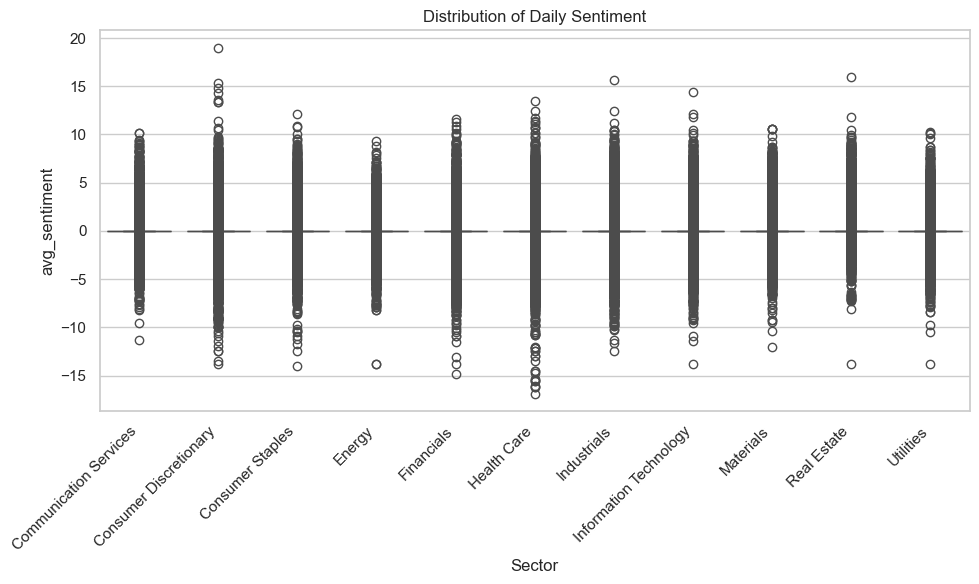

In [ ]:
# Identifying Top 5 Sectors by total article volume
top_5_sectors = df_timeframe.groupby('Sector')['article_count'].sum().index.tolist()
print(f"Top 5 Sectors by Article Volume: {top_5_sectors}")

# Filtering the dataset for only these top 5 sectors
df_sector = df_timeframe[df_timeframe['Sector'].isin(top_5_sectors)]

# Comparing Average Sentiment across Top 5 Sectors
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sector', y='avg_sentiment', data=df_sector)
plt.title('Distribution of Daily Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### PLOT: Daily Return Volatility (Sector Comparison)

C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\2121054806.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sector_volatility = df_sector.groupby('Sector')['daily_return'].std().reset_index()


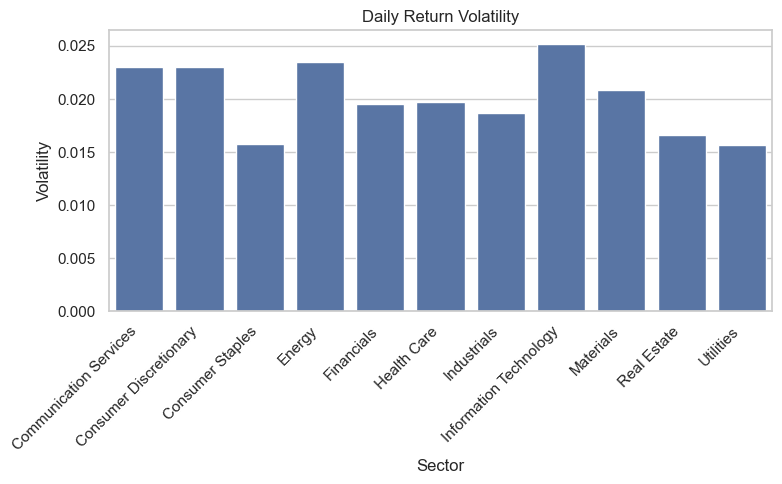

In [ ]:
# Comparing Volatility (Risk) across Top 5 Sectors

# Volatility is calculated as the standard deviation of daily returns
sector_volatility = df_sector.groupby('Sector')['daily_return'].std().reset_index()
sector_volatility.rename(columns={'daily_return': 'Volatility'}, inplace=True)

# Plotting daily return volatility
plt.figure(figsize=(8, 5))
sns.barplot(x='Sector', y='Volatility', data=sector_volatility)
plt.title('Daily Return Volatility')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### PLOT: Distrubition of Daily Sentiment (Top 10 Most Talked about Industries)

C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\3179655261.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_10_industries = df_timeframe.groupby('Industry')['article_count'].sum().nlargest(10).index.tolist()
C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\3179655261.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


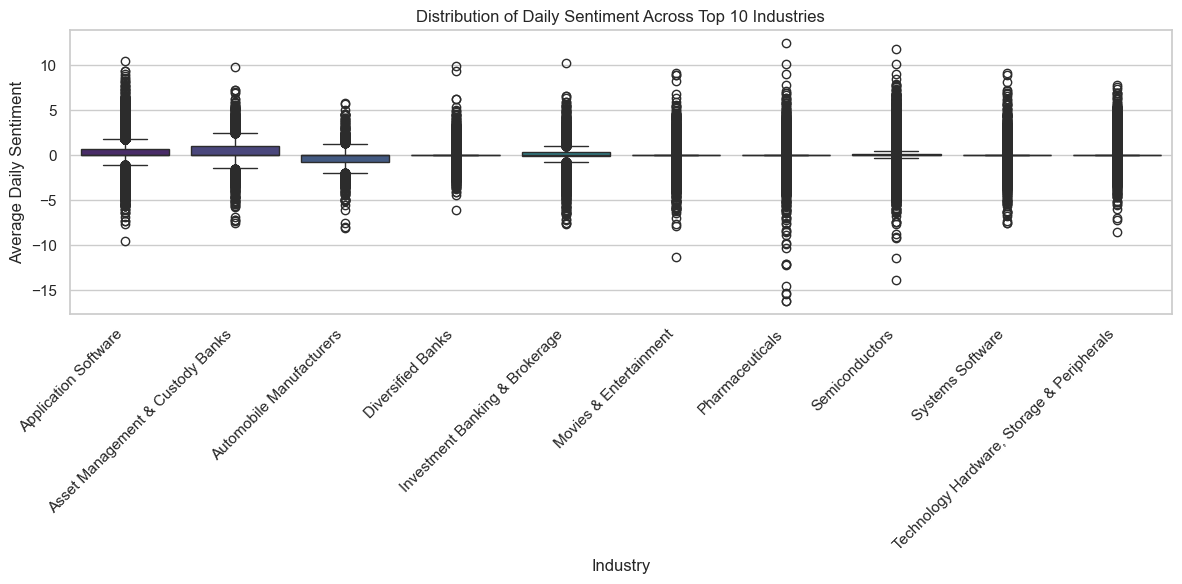

In [25]:
# Identify the Top 10 Industries by total article volume
top_10_industries = df_timeframe.groupby('Industry')['article_count'].sum().nlargest(10).index.tolist()

# Filter the dataset and make a copy to avoid warnings
df_top10_ind = df_timeframe[df_timeframe['Industry'].isin(top_10_industries)].copy()

# Fix the x-axis text overlap by converting to standard strings
df_top10_ind['Industry'] = df_top10_ind['Industry'].astype(str)

# Calculate the median sentiment for these top 10 to sort the plot
industry_order = df_top10_ind.groupby('Industry')['avg_sentiment'].median().sort_values(ascending=False).index

# Create the improved boxplot WITH the outlier dots
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='Industry', 
    y='avg_sentiment', 
    data=df_top10_ind, 
    order=industry_order, 
    palette='viridis'
    # showfliers=False has been removed, so the dots will return!
)

plt.title('Distribution of Daily Sentiment Across Top 10 Industries')
plt.xticks(rotation=45, ha='right') 
plt.ylabel('Average Daily Sentiment')
plt.tight_layout()
plt.show()

### Correlation Map

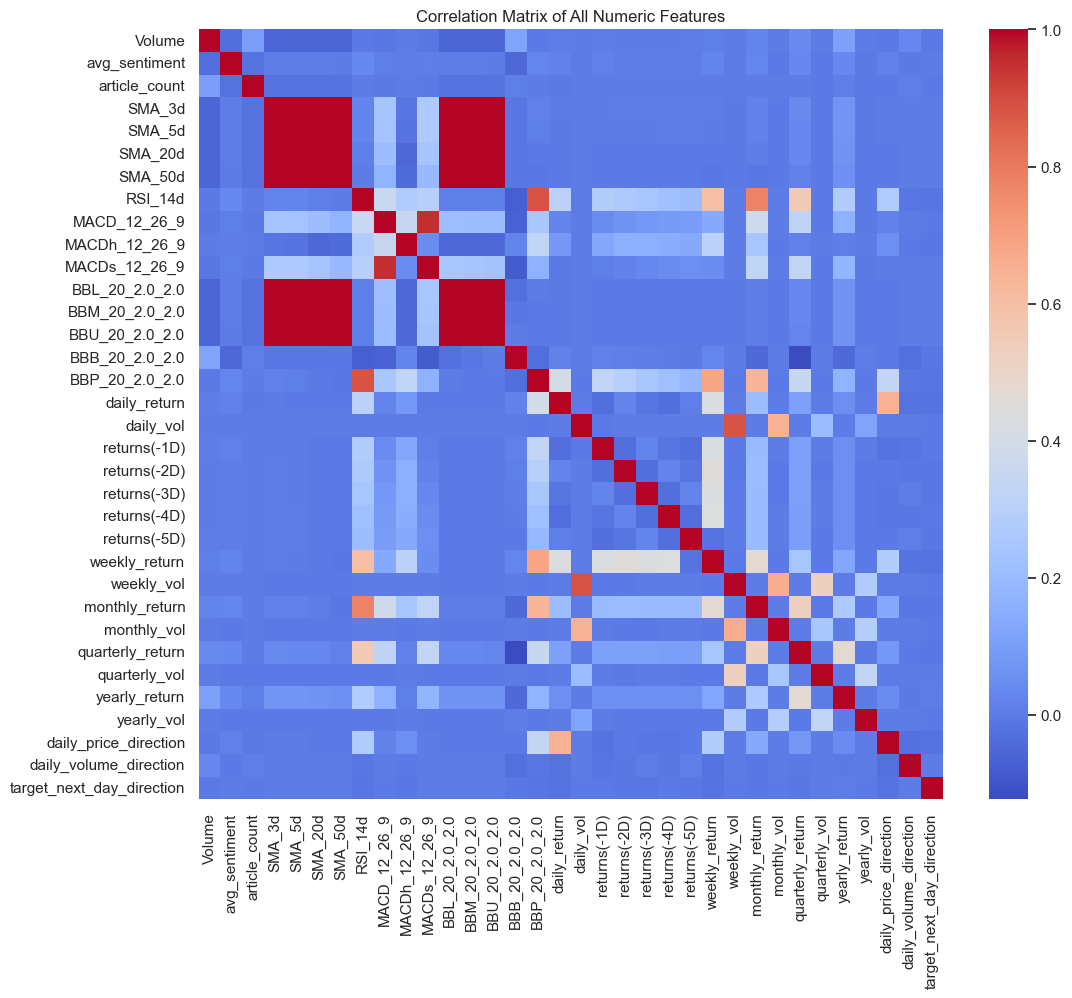

In [26]:
# Select only numeric columns for the correlation matrix
numeric_cols = df.select_dtypes(include=np.number)
raw_prices = ['Open', 'High', 'Low', 'Close']
numeric_cols = numeric_cols.drop(columns = raw_prices)

corr_matrix = numeric_cols.corr()

# Heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of All Numeric Features')
plt.show()

### Moving Average of Articles (Sector)

C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\2167990690.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sector_articles = df_timeframe.groupby(['Date', 'Sector'])['article_count'].sum().reset_index()


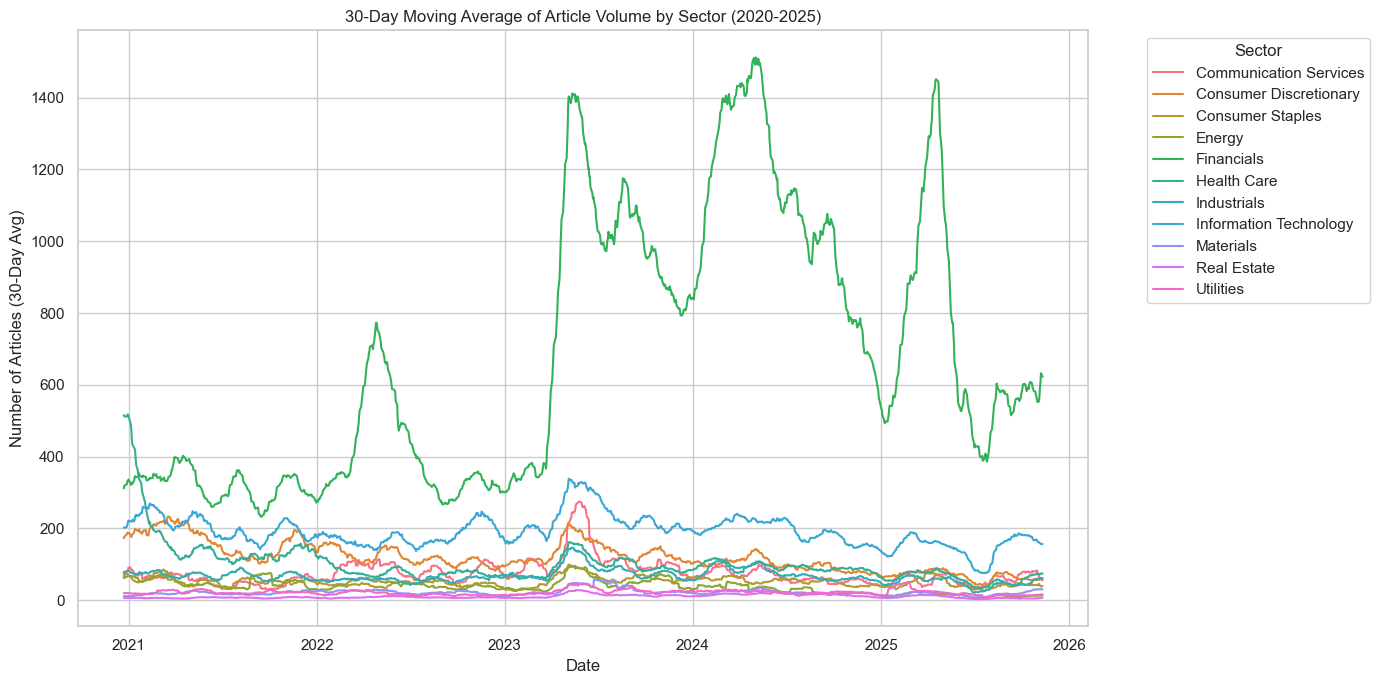

In [ ]:
# Grouping by Date and Sector, summing the daily articles to get the total per sector per day
daily_sector_articles = df_timeframe.groupby(['Date', 'Sector'])['article_count'].sum().reset_index()

# Pivoting the dataframe so Dates are the index and Sectors are the columns
pivot_articles = daily_sector_articles.pivot(index='Date', columns='Sector', values='article_count')

# Applying a 30-day rolling average to smooth the data for readability
smoothed_articles = pivot_articles.rolling(window=30).mean()

# Creating the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=smoothed_articles, dashes=False, linewidth=1.5)

plt.title('30-Day Moving Average of Article Volume by Sector (2020-2025)')
plt.xlabel('Date')
plt.ylabel('Number of Articles (30-Day Avg)')

# Move the legend outside the plot so it doesn't cover the data lines
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Moving average of Daily Returns by sector (2023)

C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\777846195.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sector_returns = df_year.groupby(['Date', 'Sector'])['daily_return'].mean().reset_index()


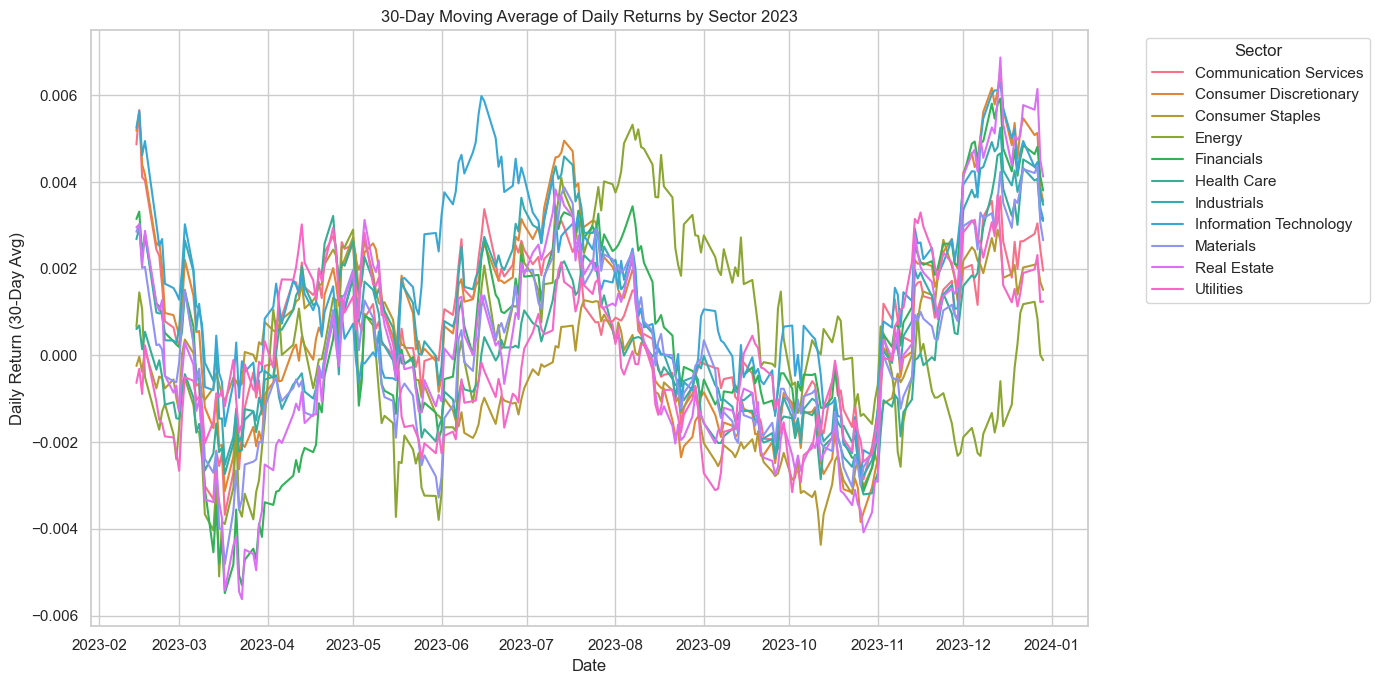

In [ ]:
# Creating variables for date filtering and window-period
year = 2023
start_date = pd.to_datetime(f'{year}-01-01')
end_date = pd.to_datetime(f'{year}-12-31')
df_year = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()
moving_avg_period = 30

# PLOT 1: 30-Day Moving Average of Daily Returns by Sector

# Calculating the mean daily return for each sector on each day
daily_sector_returns = df_year.groupby(['Date', 'Sector'])['daily_return'].mean().reset_index()

# Pivoting so Date is the index and Sectors are the columns
pivot_sector_returns = daily_sector_returns.pivot(index='Date', columns='Sector', values='daily_return')

# Applying a 30-day rolling average to smooth the volatility
smoothed_sector_returns = pivot_sector_returns.rolling(window=moving_avg_period).mean()

# Creating the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=smoothed_sector_returns, dashes=False, linewidth=1.5)

plt.title(f'{moving_avg_period}-Day Moving Average of Daily Returns by Sector {year}')
plt.xlabel('Date')
plt.ylabel(f'Daily Return ({moving_avg_period}-Day Avg)')
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



### Moving Average of Daily Returns (by period window) by Top Industries

C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\3517206758.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_15_industries_20 = df_year.groupby('Industry')['article_count'].sum().nlargest(top_n).index.tolist()


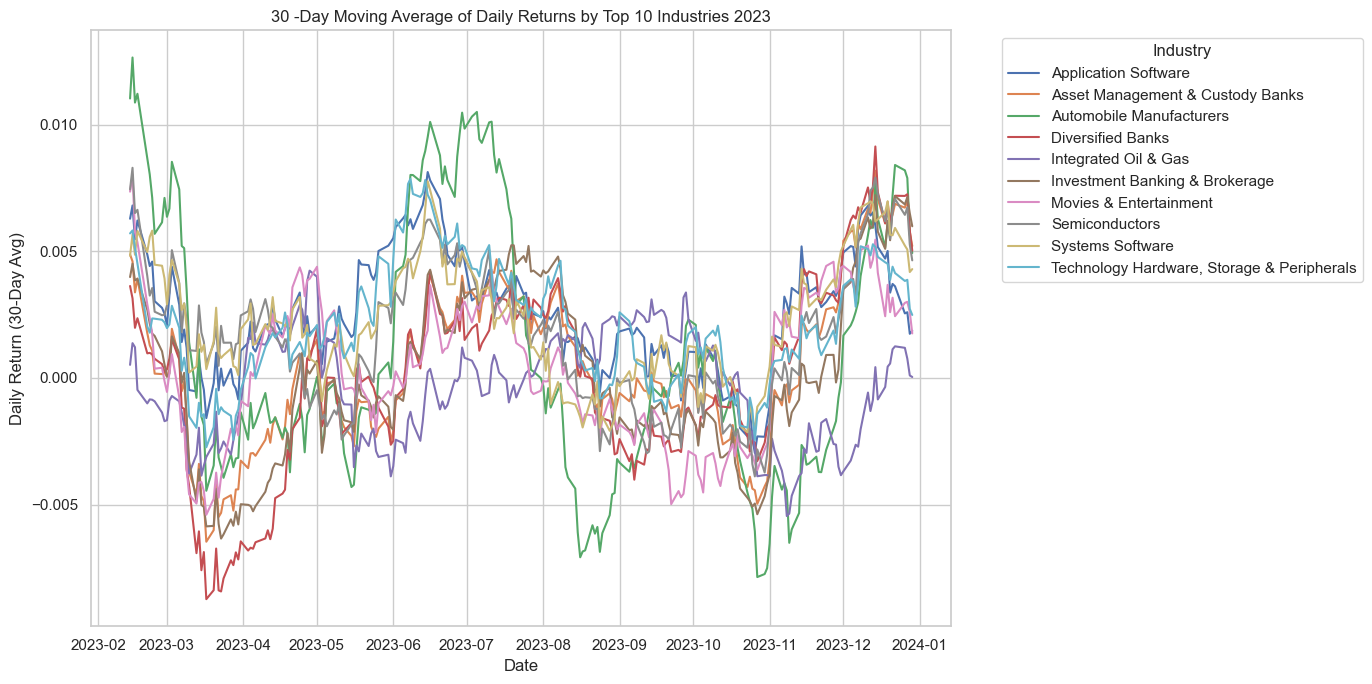

In [ ]:
# PLOT 2: Moving Average of Daily Returns (by period window) by Top Industries

top_n = 10

# Identifying Top Industries by total article volume within the 2020-2024 timeframe
top_15_industries_20 = df_year.groupby('Industry')['article_count'].sum().nlargest(top_n).index.tolist()

# Filtering the dataset and make a copy to avoid warnings
df_top15_ind_20 = df_year[df_year['Industry'].isin(top_15_industries_20)].copy()

# Converting 'Industry' to standard strings so pandas forgets the other industries!
df_top15_ind_20['Industry'] = df_top15_ind_20['Industry'].astype(str)

# Calculating mean daily return for each industry on each day
daily_industry_returns_20 = df_top15_ind_20.groupby(['Date', 'Industry'])['daily_return'].mean().reset_index()

# Pivoting so Date is the index and Industries are the columns
pivot_industry_returns_20 = daily_industry_returns_20.pivot(index='Date', columns='Industry', values='daily_return')

# Applying the 15-day rolling average
smoothed_industry_returns_20 = pivot_industry_returns_20.rolling(window=moving_avg_period).mean()

# Creating the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=smoothed_industry_returns_20, dashes=False, linewidth=1.5)

plt.title(f'{moving_avg_period} -Day Moving Average of Daily Returns by Top {top_n} Industries {year}')
plt.xlabel('Date')
plt.ylabel(f'Daily Return ({moving_avg_period}-Day Avg)')
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [30]:
df.head()

,Date,Ticker,Company,Sector,Industry,Open,High,Low,Close,Volume,...,weekly_vol,monthly_return,monthly_vol,quarterly_return,quarterly_vol,yearly_return,yearly_vol,daily_price_direction,daily_volume_direction,target_next_day_direction
0,2015-02-19,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.889730,38.045314,37.560253,37.660927,3737300,...,0.120025,0.084893,-0.257529,0.000261,0.385622,0.038169,-0.447524,-1,-1,1
1,2015-02-20,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,37.606019,38.539534,37.413825,38.393101,2971900,...,1.255369,0.099319,0.091968,0.030704,-0.495553,0.033414,-0.540770,1,-1,0
2,2015-02-23,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.338183,38.402248,37.972101,38.191750,1967900,...,-0.110312,0.052459,-0.594799,0.025298,-0.509509,0.045327,-0.415232,-1,-1,1
3,2015-02-24,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.091068,38.539523,38.072763,38.493763,1922100,...,-0.331629,0.083741,0.265122,0.021886,-0.165683,0.045982,-0.425404,1,-1,1
4,2015-02-25,A,Agilent Technologies Inc,Health Care,Life Sciences Tools & Services,38.750024,38.887307,38.521221,38.621895,2343500,...,-0.739819,0.077905,0.551062,0.001262,-0.558347,0.046881,-0.503326,1,1,1


## Train / Test Split (numerical only)

80/20 split
    - sorted by date not group to avoid leakage for split


### Option 1: 80/20 split

In [ ]:
# Sorting by date
df_date_sorted = df.sort_values(by='Date').copy()

# Finding date point that is at 80%
unique_dates = df_date_sorted['Date'].unique()
split_index = int(len(unique_dates)*0.8)
cutoff_date = unique_dates[split_index]

# Gettin start and end dates
start_date = df_date_sorted['Date'].min()
end_date = df_date_sorted['Date'].max()

print(f"Data ranges from: {start_date.date()} to {end_date.date()}")
print(f"Splitting data at cutoff date: {cutoff_date}")

Data ranges from: 2015-02-19 to 2025-11-10
Splitting data at cutoff date: 2023-09-18 00:00:00


In [ ]:
# Train / Test Split using filtered cuttoff date
train = df_date_sorted[df_date_sorted['Date'] < cutoff_date]
test = df_date_sorted[df_date_sorted['Date'] >= cutoff_date]

# Creating list of features to exclude
exclude_columns = [
    'Date', 'Ticker', 'Company',        # Identifiers / Text
    'Sector', 'Industry',               # Categorical
    'Open', 'High', 'Low', 'Close',     # Raw prices (use engineered features instead)
    'Volume',                           # Raw volume
    'target_next_day_direction'         # The target variable
]

# Separating included features (X) and target (y)
X_train = train.drop(columns = exclude_columns)
y_train = train['target_next_day_direction']

X_test = test.drop(columns = exclude_columns)
y_test = test['target_next_day_direction']

# Verify the shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Optional: Print the exact features being used to double-check
print("\nFeatures used for modeling:")
print(X_train.columns)

X_train shape: (1030931, 36)
y_train shape: (1030931,)
X_test shape: (269180, 36)
y_test shape: (269180,)

Features used for modeling:
Index(['avg_sentiment', 'article_count', 'SMA_3d', 'SMA_5d', 'SMA_20d',
       'SMA_50d', 'RSI_14d', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
       'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0',
       'BBP_20_2.0_2.0', 'Trend_Long', 'Trend_Short', 'Reversal_Long',
       'Reversal_Short', 'daily_return', 'daily_vol', 'returns(-1D)',
       'returns(-2D)', 'returns(-3D)', 'returns(-4D)', 'returns(-5D)',
       'weekly_return', 'weekly_vol', 'monthly_return', 'monthly_vol',
       'quarterly_return', 'quarterly_vol', 'yearly_return', 'yearly_vol',
       'daily_price_direction', 'daily_volume_direction'],
      dtype='object')


### Model: Majority and Random Baselines

In [33]:
# FUNCTION: Getting Metrics for Evaluation
def metrics(model_name, y_true, y_pred, y_prob):

    # Getting Metrics Values
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    log = log_loss(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    # Print Confusion Matrix
    print(f'\n--- Confusion Matrix: {model_name} ---')
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm, 
        index=['Actual 0', 'Actual 1'], 
        columns=['Predicted 0', 'Predicted 1'])
    print(cm_df)

    # Python has diffent matrix setup than R...
    #           Predicted
    #             0   1
    # Actual 0 [[TN, FP],
    #        1  [FN, TP]]
    
    TN, FP, FN, TP = cm.ravel()
    print(f"\nTrue Negatives (TN):  {TN}")
    print(f"False Positives (FP): {FP}")
    print(f"False Negatives (FN): {FN}")
    print(f"True Positives (TP):  {TP}")

    # Creating dictionary for dataframe return
    metrics_dict = {
        'Model': [model_name],
        'Accuracy': [accuracy],
        'ROC-AUC': [roc_auc],
        'F1 Score': [f1],
        'Precision': [precision],
        'Recall': [recall],
        'Log Loss': [log],
        'Brier Score': [brier]
    }

    return pd.DataFrame(metrics_dict)

In [34]:

# MODEL: MAJORITY BASELINE
majority_class = y_train.mode()[0]
y_pred_majority = np.full(len(y_test), majority_class)

# The probability of class 1 is simply 1.0 if majority is 1, else 0.0
y_prob_majority = np.full(len(y_test), majority_class)

majority_metrics = metrics('Majority Baseline', y_test, y_pred_majority, y_prob_majority)


# MODEL: RANDOM BASELINE

p = y_train.mean() # The historical probability of Class 1 ('Up')
y_pred_random = np.random.binomial(1, p, size=len(y_test))

# The predicted probability of class 1 is just the historical mean 'p' for all rows
y_prob_random = np.full(len(y_test), p)

random_metrics = metrics('Random Baseline', y_test, y_pred_random, y_prob_random)


--- Confusion Matrix: Majority Baseline ---
          Predicted 0  Predicted 1
Actual 0            0       128330
Actual 1            0       140850

True Negatives (TN):  0
False Positives (FP): 128330
False Negatives (FN): 0
True Positives (TP):  140850

--- Confusion Matrix: Random Baseline ---
          Predicted 0  Predicted 1
Actual 0        60966        67364
Actual 1        67148        73702

True Negatives (TN):  60966
False Positives (FP): 67364
False Negatives (FN): 67148
True Positives (TP):  73702


In [35]:
# Displaying metrics from models
model_results = pd.concat([majority_metrics, random_metrics], ignore_index=True)
print("\n\n--- Summary of Model Metrics ---")
display(model_results.style.hide(axis="index"))



--- Summary of Model Metrics ---


Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall,Log Loss,Brier Score
Majority Baseline,0.523256,0.500000,0.687023,0.523256,1.000000,17.183602,0.476744
Random Baseline,0.500290,0.500000,0.522865,0.522465,0.523266,0.692065,0.249459


### Model: Random Forest (Initial - Numeric Only)

In [ ]:
# Preparing parameters for cross-validation
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'n_estimators': [200],              # Number of trees
    'max_depth': [10, 20],              # Maximum depth to prevent overfitting
    'min_samples_leaf': [10, 50]        # Minimum samples in a leaf to ensure generalizable rules
}

# Initializing the Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Setting up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',  
    verbose=2,          
    n_jobs=-1           
)

# Training the model using Grid Search
print("Starting GridSearchCV... (Grab a coffee, this will take some time!)")
grid_search.fit(X_train, y_train)

# Displaying the Best Parameters and the Best Model
print("\n--- GRID SEARCH COMPLETE ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_

# Predicting on the test set
print("\nMaking predictions on the test set...")
y_pred_rf = best_rf_model.predict(X_test)           
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]


Starting GridSearchCV... (Grab a coffee, this will take some time!)
Fitting 5 folds for each of 4 candidates, totalling 20 fits

--- GRID SEARCH COMPLETE ---
Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 200}
Best Cross-Validation AUC: 0.5091

Making predictions on the test set...


In [ ]:
# Getting metrics of Random Forest (Numeric)
rf_num_metrics = metrics('Random Forest (Numeric)', y_test, y_pred_rf, y_prob_rf)

# Displaying metrics from models
model_results = pd.concat([model_results, rf_num_metrics], ignore_index=True)
print("\n\n--- Summary of Model Metrics ---")
display(model_results.style.hide(axis="index"))



--- Confusion Matrix: Random Forest (Numeric) ---
          Predicted 0  Predicted 1
Actual 0         9668       118662
Actual 1         9755       131095

True Negatives (TN):  9668
False Positives (FP): 118662
False Negatives (FN): 9755
True Positives (TP):  131095


--- Summary of Model Metrics ---


Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall,Log Loss,Brier Score
Majority Baseline,0.523256,0.500000,0.687023,0.523256,1.000000,17.183602,0.476744
Random Baseline,0.500290,0.500000,0.522865,0.522465,0.523266,0.692065,0.249459
Random Forest (Numeric),0.522933,0.510557,0.671237,0.524890,0.930742,0.691977,0.249415


--- FEATURE IMPORTANCE SCORES ---
               Feature  Importance
          returns(-5D)    0.081637
          daily_return    0.071939
          returns(-1D)    0.064708
          returns(-2D)    0.055277
          returns(-3D)    0.055190
         weekly_return    0.049999
          returns(-4D)    0.043380
      quarterly_return    0.040935
        BBP_20_2.0_2.0    0.040928
        monthly_return    0.037295
         quarterly_vol    0.036886
         yearly_return    0.036775
               RSI_14d    0.036110
        BBB_20_2.0_2.0    0.034347
             daily_vol    0.032474
           monthly_vol    0.031988
         MACDh_12_26_9    0.028019
            weekly_vol    0.027103
            yearly_vol    0.025305
         MACDs_12_26_9    0.025216
          MACD_12_26_9    0.022735
 daily_price_direction    0.018338
        BBL_20_2.0_2.0    0.013221
               SMA_50d    0.012765
        BBU_20_2.0_2.0    0.012215
                SMA_3d    0.011850
               SMA_20

C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\102697542.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


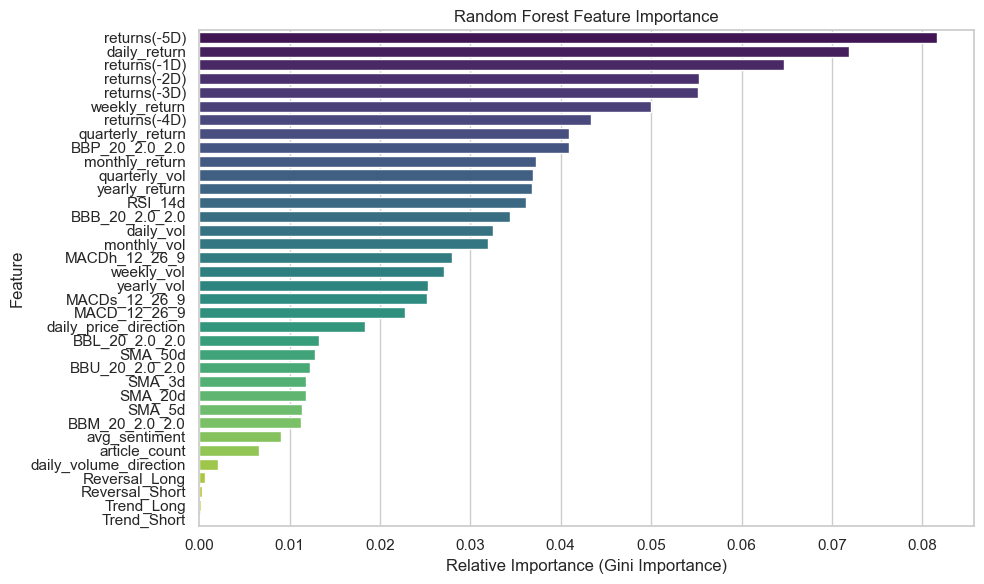

In [ ]:
# Extracting the feature names and importances from best tuned model
feature_names = best_rf_model.feature_names_in_
importances = best_rf_model.feature_importances_

# Creating a DataFrame pairing the feature names with their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Displaying the exact numeric values
print("--- FEATURE IMPORTANCE SCORES ---")
print(feature_importance_df.to_string(index=False))

# Creating a horizontal bar chart for visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Model: XGBoost Classifier (Initial - Numeric Only)

In [ ]:
# Creating list columns to exclude
exclude_columns_xgb = [
    'Date', 'Ticker', 'Company',        # Identifiers / Text
    'Sector', 'Industry',               # Categorical
    'Open', 'High', 'Low', 'Close',     # Raw prices
    'Volume',                           # Raw Volume
    'target_next_day_direction'         # The target variable
]

# Splitting train/test datasets
X_train_xgb = train.drop(columns = exclude_columns_xgb)
y_train_xgb = train['target_next_day_direction']

X_test_xgb = test.drop(columns = exclude_columns_xgb)
y_test_xgb = test['target_next_day_direction']

# Printing the exact features being used to double-check
print("\nFeatures used for modeling:")
print(X_train_xgb.columns)


Features used for modeling:
Index(['avg_sentiment', 'article_count', 'SMA_3d', 'SMA_5d', 'SMA_20d',
       'SMA_50d', 'RSI_14d', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
       'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0',
       'BBP_20_2.0_2.0', 'Trend_Long', 'Trend_Short', 'Reversal_Long',
       'Reversal_Short', 'daily_return', 'daily_vol', 'returns(-1D)',
       'returns(-2D)', 'returns(-3D)', 'returns(-4D)', 'returns(-5D)',
       'weekly_return', 'weekly_vol', 'monthly_return', 'monthly_vol',
       'quarterly_return', 'quarterly_vol', 'yearly_return', 'yearly_vol',
       'daily_price_direction', 'daily_volume_direction'],
      dtype='object')


## Model: XGBoost Classifier (Numerical)

In [40]:
# Defining parameters
tscv_xgb = TimeSeriesSplit(n_splits=5)
param_grid_xgb = {
    'n_estimators': [50, 75, 100, 150],
    'max_depth': [3, 5, 6, 7, 8],
    'learning_rate': [0.05, 0.1]
}

# Initializing the base XGBoost model
xgb_num_model = XGBClassifier(
    # tree_method='hist',           # Use to include categorical
    # enable_categorical=True,      # Use to include categorical
    random_state=42,
    n_jobs=-1
)

# Setting up the Grid Search
grid_search_xgb = GridSearchCV(
    estimator=xgb_num_model,
    param_grid=param_grid_xgb,
    cv=tscv_xgb,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1
)

# Running the search on your training data
print("Searching for the best parameters. This may take a moment...")
grid_search_xgb.fit(X_train_xgb, y_train_xgb)


Searching for the best parameters. This may take a moment...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [50, 75, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [ ]:
# Viewing the results of hyperparameters
best_xgb_model = grid_search_xgb.best_estimator_
print("\n--- XGBOOST GRID SEARCH COMPLETE ---")
print(f"Best Hyperparameters: {grid_search_xgb.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search_xgb.best_score_:.4f}")

# Predicting using model's best hyperparameters
print("\nEvaluating the Best XGBoost Model on the Test Set...")
y_pred_xgb_best = best_xgb_model.predict(X_test_xgb)
y_pred_proba_xgb_best = best_xgb_model.predict_proba(X_test_xgb)[:, 1]


--- XGBOOST GRID SEARCH COMPLETE ---
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 50}
Best Cross-Validation AUC: 0.5087

Evaluating the Best XGBoost Model on the Test Set...


In [42]:
xgb_num_metrics = metrics("XGBoost (Numeric)", y_test_xgb, y_pred_xgb_best, y_pred_proba_xgb_best)

# Displaying metrics from models
model_results = pd.concat([model_results, xgb_num_metrics], ignore_index=True)
print("\n\n--- Summary of Model Metrics ---")
display(model_results.style.hide(axis="index"))



--- Confusion Matrix: XGBoost (Numeric) ---
          Predicted 0  Predicted 1
Actual 0        14216       114114
Actual 1        14790       126060

True Negatives (TN):  14216
False Positives (FP): 114114
False Negatives (FN): 14790
True Positives (TP):  126060


--- Summary of Model Metrics ---


Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall,Log Loss,Brier Score
Majority Baseline,0.523256,0.500000,0.687023,0.523256,1.000000,17.183602,0.476744
Random Baseline,0.500290,0.500000,0.522865,0.522465,0.523266,0.692065,0.249459
Random Forest (Numeric),0.522933,0.510557,0.671237,0.524890,0.930742,0.691977,0.249415
XGBoost (Numeric),0.521123,0.506998,0.661691,0.524869,0.894995,0.692546,0.249694


NOTE: True Negative improved, while True Positive decreased

--- FEATURE IMPORTANCE SCORES ---
               Feature  Importance
          daily_return    0.051955
          returns(-1D)    0.047730
          returns(-5D)    0.047367
        monthly_return    0.039511
          returns(-2D)    0.039488
          returns(-3D)    0.038963
      quarterly_return    0.037784
         MACDs_12_26_9    0.036870
          returns(-4D)    0.036525
               RSI_14d    0.034626
           Trend_Short    0.034246
         quarterly_vol    0.033890
         yearly_return    0.033223
        BBB_20_2.0_2.0    0.033109
        BBP_20_2.0_2.0    0.032575
         weekly_return    0.031077
         MACDh_12_26_9    0.030845
           monthly_vol    0.029062
            Trend_Long    0.028631
             daily_vol    0.027886
          MACD_12_26_9    0.027735
                SMA_5d    0.024887
            weekly_vol    0.024852
               SMA_50d    0.024105
            yearly_vol    0.023347
        BBL_20_2.0_2.0    0.021444
        BBU_20_2.0_2.

C:\Users\jplac\AppData\Local\Temp\ipykernel_15776\4008556894.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, palette='viridis')


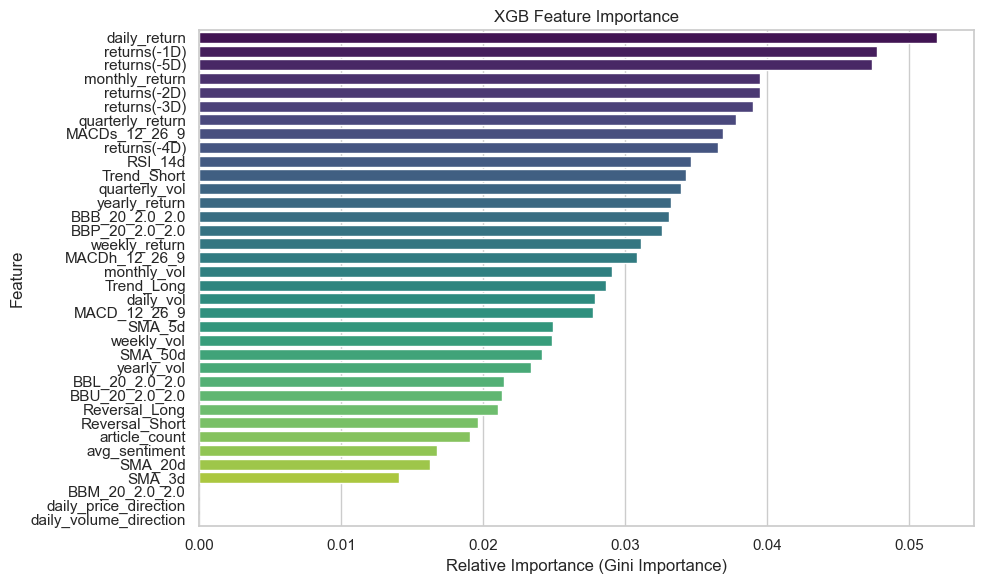

In [ ]:
# Extracting the feature names and importances from best tuned model
feature_names_xgb = best_xgb_model.feature_names_in_
importances_xgb = best_xgb_model.feature_importances_

# Creating a DataFrame pairing the feature names with their importance scores
feature_importance_df_xgb = pd.DataFrame({
    'Feature': feature_names_xgb,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

# Displaing the exact numeric values
print("--- FEATURE IMPORTANCE SCORES ---")
print(feature_importance_df_xgb.to_string(index=False))

# Creating a horizontal bar chart for visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, palette='viridis')

plt.title('XG Feature Importance')
plt.xlabel('Relative Importance (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

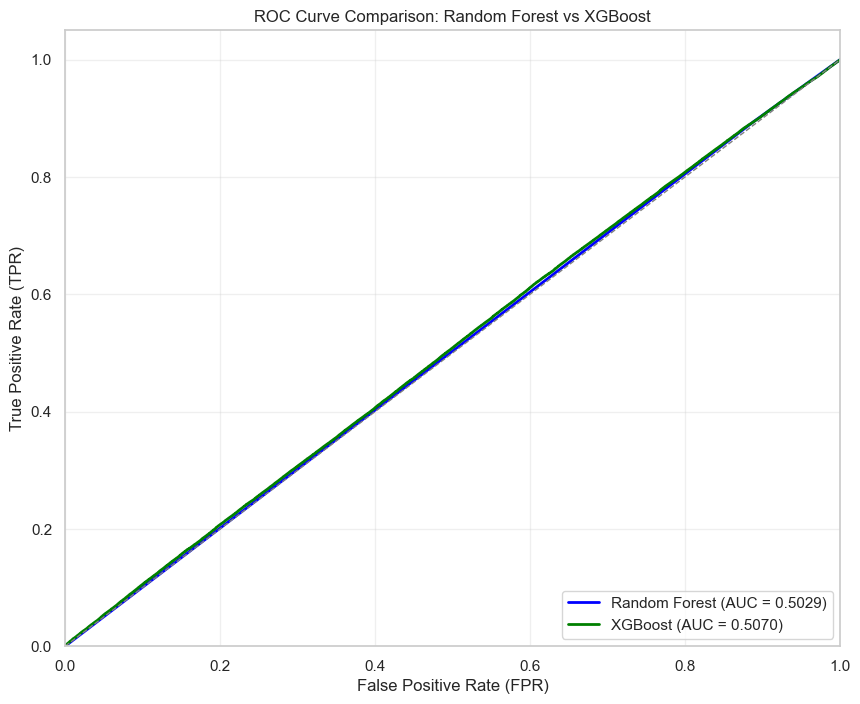

In [ ]:
# Calculating ROC Curve for Random Forest
FP_rate_rf, TP_rate_rf, _ = roc_curve(y_test, y_pred_xgb_best)
roc_auc_rf = auc(FP_rate_rf, TP_rate_rf)

# Calculating ROC Curve for XGBoost
FP_rate_xgb, TP_rate_xgb, _ = roc_curve(y_test_xgb, y_pred_proba_xgb_best)
roc_auc_xgb = auc(FP_rate_xgb, TP_rate_xgb)

# Plotting the ROC Curves
plt.figure(figsize=(10, 8))

# Plotting Random Forest ROC and XGBoost ROC
plt.plot(FP_rate_rf, TP_rate_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(FP_rate_xgb, TP_rate_xgb, color='green', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison: Random Forest vs XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Model: XGBoost Classifier (Numerical + Categorical)

In [ ]:
# Creating list of excluded features (X)
exclude_columns_xgb2 = [
    'Date', 'Ticker', 'Company',        # Identifiers / Text
    'Sector', 'Industry',               # Categorical
    'Open', 'High', 'Low', 'Close',     # Raw prices
    'Volume',                           # Raw Volume
    'target_next_day_direction'         # The target variable
]

# Separating features (X) and target (y)
X_train_xgb2 = train.drop(columns = exclude_columns_xgb)
y_train_xgb2 = train['target_next_day_direction']

X_test_xgb2 = test.drop(columns = exclude_columns_xgb)
y_test_xgb2 = test['target_next_day_direction']

# Optional: Print the exact features being used to double-check
print("\nFeatures used for modeling:")
print(X_train_xgb2.columns)


Features used for modeling:
Index(['avg_sentiment', 'article_count', 'SMA_3d', 'SMA_5d', 'SMA_20d',
       'SMA_50d', 'RSI_14d', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
       'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0',
       'BBP_20_2.0_2.0', 'Trend_Long', 'Trend_Short', 'Reversal_Long',
       'Reversal_Short', 'daily_return', 'daily_vol', 'returns(-1D)',
       'returns(-2D)', 'returns(-3D)', 'returns(-4D)', 'returns(-5D)',
       'weekly_return', 'weekly_vol', 'monthly_return', 'monthly_vol',
       'quarterly_return', 'quarterly_vol', 'yearly_return', 'yearly_vol',
       'daily_price_direction', 'daily_volume_direction'],
      dtype='object')


In [ ]:
# Generating model with enable_categorical=True and use the 'hist' tree method
model = xgb.XGBClassifier(
    n_estimators=50, 
    max_depth=8, 
    learning_rate=0.01, 
    random_state=42,
    tree_method='hist',           
    enable_categorical=True       
)
model.fit(X_train_xgb2, y_train_xgb2)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
# Getting predictions and probabilities
pred_xgb2 = model.predict(X_test_xgb2)
probs_xgb2 = model.predict_proba(X_test_xgb2)[:, 1]

xgb_cat_metrics = metrics("XGBoost (Numeric + Categorical)", y_test_xgb2, pred_xgb2, probs_xgb2)

# Displaying metrics from models
model_results = pd.concat([model_results, xgb_cat_metrics], ignore_index=True)
print("\n\n--- Summary of Model Metrics ---")
display(model_results.style.hide(axis="index"))



--- Confusion Matrix: XGBoost (Numeric + Categorical) ---
          Predicted 0  Predicted 1
Actual 0         1433       126897
Actual 1         1545       139305

True Negatives (TN):  1433
False Positives (FP): 126897
False Negatives (FN): 1545
True Positives (TP):  139305


--- Summary of Model Metrics ---


Model,Accuracy,ROC-AUC,F1 Score,Precision,Recall,Log Loss,Brier Score
Majority Baseline,0.523256,0.500000,0.687023,0.523256,1.000000,17.183602,0.476744
Random Baseline,0.500290,0.500000,0.522865,0.522465,0.523266,0.692065,0.249459
Random Forest (Numeric),0.522933,0.510557,0.671237,0.524890,0.930742,0.691977,0.249415
XGBoost (Numeric),0.521123,0.506998,0.661691,0.524869,0.894995,0.692546,0.249694
XGBoost (Numeric + Categorical),0.522840,0.505234,0.684458,0.523306,0.989031,0.692072,0.249462


--- Exact Feature Importance Scores (Normalized) ---
         Feature  Relative Importance  Percentage (%)
    daily_return             0.086458            8.65
    returns(-1D)             0.067111            6.71
    returns(-5D)             0.063620            6.36
   MACDs_12_26_9             0.051923            5.19
quarterly_return             0.046508            4.65
    returns(-3D)             0.046289            4.63
   quarterly_vol             0.043451            4.35
  monthly_return             0.042148            4.21
    returns(-2D)             0.041275            4.13
    returns(-4D)             0.038009            3.80
         RSI_14d             0.036590            3.66
  BBB_20_2.0_2.0             0.035784            3.58
   yearly_return             0.035427            3.54
  BBP_20_2.0_2.0             0.034099            3.41
   MACDh_12_26_9             0.033287            3.33
   weekly_return             0.031382            3.14
     monthly_vol             

<Figure size 1000x800 with 0 Axes>

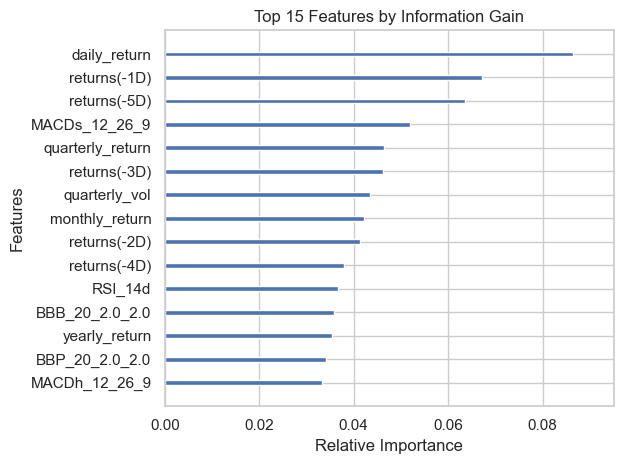

In [59]:
# Visualizing Feature Importance

# Get the exact numerical scores for 'gain'
raw_scores = model.get_booster().get_score(importance_type='gain')

# Normalizing raw scoresto sort in library
total_gain = sum(raw_scores.values())
normalized_scores = {feature: (score / total_gain) for feature, score in raw_scores.items()}
sorted_normalized = dict(sorted(normalized_scores.items(), key=lambda item: item[1], reverse=True))

# Converting the sorted dictionary into a DataFrame
normalized_df = pd.DataFrame({
    'Feature': list(sorted_normalized.keys()),
    'Relative Importance': list(sorted_normalized.values())
})

# Createing a clean percentage column for easier reading
normalized_df['Percentage (%)'] = (normalized_df['Relative Importance'] * 100).round(2)

# Print the clean DataFrame without the index numbers
print("--- Exact Feature Importance Scores (Normalized) ---")
print(normalized_df.to_string(index=False))

# Displaying importance features
plt.figure(figsize=(10, 8))

# Plotting using xgb's built-in plot_importance()
xgb.plot_importance(
    normalized_scores, 
    max_num_features=15,       # Change this to see more or fewer features
    show_values=False,         # Hides the raw numbers on the bars for a cleaner look
    title='Top 15 Features by Information Gain',
    xlabel = 'Relative Importance'
)

plt.tight_layout()
plt.show()


NOTE: Features show model priorities 


---

# ---CONTINUE WORKING BELOW---

In [60]:
print(df.columns)

Index(['Date', 'Ticker', 'Company', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Volume', 'avg_sentiment', 'article_count', 'SMA_3d',
       'SMA_5d', 'SMA_20d', 'SMA_50d', 'RSI_14d', 'MACD_12_26_9',
       'MACDh_12_26_9', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0',
       'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'Trend_Long',
       'Trend_Short', 'Reversal_Long', 'Reversal_Short', 'daily_return',
       'daily_vol', 'returns(-1D)', 'returns(-2D)', 'returns(-3D)',
       'returns(-4D)', 'returns(-5D)', 'weekly_return', 'weekly_vol',
       'monthly_return', 'monthly_vol', 'quarterly_return', 'quarterly_vol',
       'yearly_return', 'yearly_vol', 'daily_price_direction',
       'daily_volume_direction', 'target_next_day_direction'],
      dtype='object')


## CandleStick and MACD Plot

This is not part of the analysis, but a way for me to understand how the MACD works

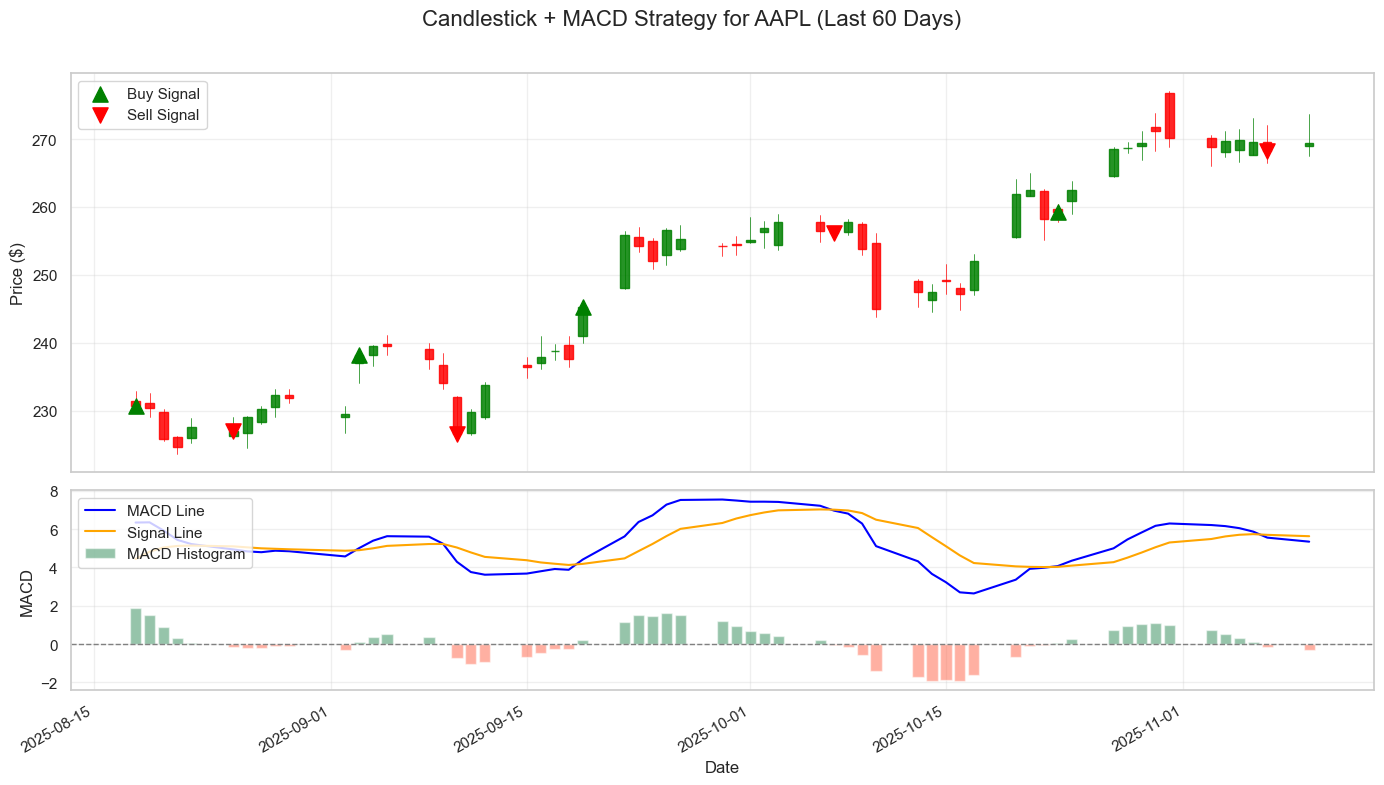

In [58]:
# import matplotlib.dates as mdates
# from mplfinance.original_flavor import candlestick_ohlc

# # Getting Ticker stock price data
# ticker_to_plot = 'AAPL'
# df_plot = sp500_original[sp500_original['Ticker'] == ticker_to_plot].copy()
# df_plot.set_index('Date', inplace=True)

# # Recalculating MACD for the single stock to ensure data is correct
# df_plot.ta.macd(close='Close', fast=12, slow=26, signal=9, append=True)

# # Defining the MACD column names created by pandas_ta
# MACD_line = "MACD_12_26_9"
# MACD_signal = "MACDs_12_26_9"
# MACD_histogram = "MACDh_12_26_9"

# # Retaining last 60 days for a clean view
# last60 = df_plot.tail(60).copy()

# # Generating Trading Signals (Days when MACD crosses signal line)
# macd_above = last60[MACD_line] > last60[MACD_signal]
# last60["signal"] = 0
# last60.loc[macd_above & ~macd_above.shift(1, fill_value=False), "signal"] = 1   # BUY
# last60.loc[~macd_above & macd_above.shift(1, fill_value=False), "signal"] = -1  # SELL

# # Preparing Data for mplfinance
# # Create a numeric date column required by candlestick_ohlc
# last60['date_num'] = mdates.date2num(last60.index)
# ohlc = last60[["date_num", "Open", "High", "Low", "Close"]].copy()

# # Getting the specific points for buy/sell markers using the numeric date
# buy_pts = last60[last60["signal"] == 1]
# sell_pts = last60[last60["signal"] == -1]

# # Creating the Plot ---
# fig, (ax1, ax2) = plt.subplots(
#     2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
# )
# fig.suptitle(f'Candlestick + MACD Strategy for {ticker_to_plot} (Last 60 Days)', fontsize=16)

# # Panel 1: Candlesticks and Markers
# candlestick_ohlc(ax1, ohlc.values, width=0.6, colorup="green", colordown="red", alpha=0.85)

# # Plotting markers using the numeric date ('date_num') for the x-axis
# ax1.scatter(buy_pts['date_num'], buy_pts["Close"], marker="^", s=120, color="green", label="Buy Signal", zorder=5)
# ax1.scatter(sell_pts['date_num'], sell_pts["Close"], marker="v", s=120, color="red", label="Sell Signal", zorder=5)

# ax1.set_ylabel("Price ($)")
# ax1.legend(loc="upper left")
# ax1.grid(True, alpha=0.3)

# # Panel 2: MACD Indicator
# bar_colors = np.where(last60[MACD_histogram] >= 0, "seagreen", "tomato")
# ax2.bar(last60['date_num'], last60[MACD_histogram], color=bar_colors, alpha=0.5, label="MACD Histogram")
# ax2.plot(last60['date_num'], last60[MACD_line], label="MACD Line", color="blue", linewidth=1.5)
# ax2.plot(last60['date_num'], last60[MACD_signal], label="Signal Line", color="orange", linewidth=1.5)

# ax2.axhline(0, color="gray", linewidth=1, linestyle='--')
# ax2.set_ylabel("MACD")
# ax2.set_xlabel("Date")
# ax2.legend(loc="upper left")
# ax2.grid(True, alpha=0.3)

# # Formatting X-Axis
# ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
# fig.autofmt_xdate()

# plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust layout to make room for suptitle
# plt.show()

# NOTES:
overnight exchanges -SP500 only open during business hours
- there are overseas market that open before US Markets open
- add in news
  - macroeconomic stuff
    - interest rates
    - inflation
- adding key components of sp500
  - key stocks
  - key sectors
    - if tech is in downturn...it is possible that 6 months later that sp500 will go down
    - (any correlation)
- increasing resolution for more accurate predictions
  - hourly
  - minute
  - tic data
- Model can get big and you can go pretty far if you want to...